# INFO-6147-(01)-26W Deep Learning with Pytorch

## Homework 4: Denoising autoencoder cifar10

**Student Name:** Yun-Jiung Wang

**Student Number:** 1256222

**Date:** March 18th, 2026

**Description:** 

you need to implement denoising autoencoder for RGB images. For this we want to use CIFAR10 dataset.
You need to add noise to the images before you feed them to the network. This can be done as follows:

       **add random noise to the input images**
        noisy_imgs = images + noise_factor * torch.randn(*images.shape)
        # Clip the images to be between 0 and 1
        noisy_imgs = np.clip(noisy_imgs, 0., 1.)

Make sure to display samples of the images before and after adding noise.


### Import libs

In [22]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import random_split

import warnings
warnings.filterwarnings('ignore')

###  Check if CUDA is available and set PyTorch to use GPU or CPU

In [23]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


### Set the Random Seed

In [24]:
torch.manual_seed(42)

### Define transformations for the training data and testing data

In [25]:
transform = transforms.ToTensor()

###  Download and load the training data - split the training data into trainset (45000)-  valset (5000)

In [26]:
dataset = datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainset, valset =  random_split(dataset, [45000, 5000])
trainloader =  torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)
valloader =  torch.utils.data.DataLoader(valset, batch_size=64, shuffle=False)

dataset

Files already downloaded and verified


Dataset CIFAR10
    Number of datapoints: 50000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: ToTensor()

### Add Noise

In [27]:
def add_noise(images, noise_factor=0.3):
    noisy_imgs = images + noise_factor * torch.randn_like(images)
    noisy_imgs = torch.clamp(noisy_imgs, 0., 1.)
    return noisy_imgs

### Visualize Pictures 

In [28]:
def show_images(original, noisy):
    import matplotlib.pyplot as plt
    
    original = original.numpy().transpose(0,2,3,1)
    noisy = noisy.numpy().transpose(0,2,3,1)

    fig, axes = plt.subplots(2,6, figsize=(10,4))
    
    for i in range(6):
        axes[0,i].imshow(original[i])
        axes[0,i].set_title("Original")
        axes[0,i].axis('off')

        axes[1,i].imshow(noisy[i])
        axes[1,i].set_title("Noisy")
        axes[1,i].axis('off')

    plt.show()

### Define the Model

In [29]:
class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(3, 16, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1),
            nn.ReLU()
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 3, 3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

### Train the model

In [30]:
model = Autoencoder()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(5):
    for images, _ in trainloader:
        
        noisy_imgs = add_noise(images)

        outputs = model(noisy_imgs)
        loss = criterion(outputs, images)  # use clean picture as label
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch}, Loss: {loss.item()}")

Epoch 0, Loss: 0.007781789172440767
Epoch 1, Loss: 0.007487298455089331
Epoch 2, Loss: 0.008941772393882275
Epoch 3, Loss: 0.007522422820329666
Epoch 4, Loss: 0.007918349467217922


In [31]:
model.eval()

# get batch
images, _ = next(iter(trainloader))

# add noise
noisy_imgs = add_noise(images)

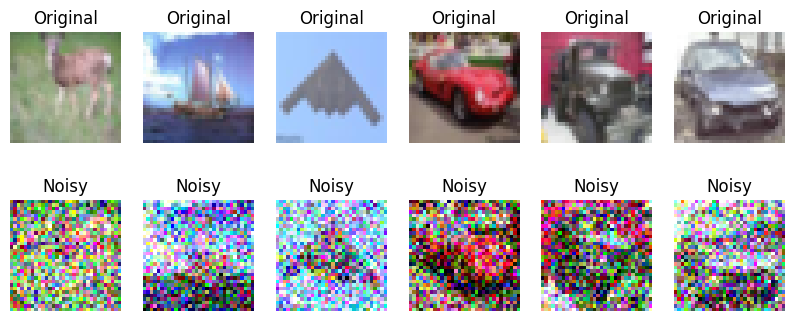

In [32]:
show_images(images,noisy_imgs)